In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import sklearn.metrics as skm
from scipy.stats import ks_2samp
import math
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr
import math
import boto3

# silence warnings
import warnings
warnings.filterwarnings('ignore')

# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning

(CVXPY) Jan 31 07:40:29 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Jan 31 07:40:29 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


#### Functions

In [2]:
def split_data(flt_prop_row):
    if flt_prop_row <= 0.60:
        return 'train'
    elif flt_prop_row <= 0.8:
        return 'test'
    else:
        return 'holdout'

In [3]:
# upload to s3
def upload_to_s3(str_local_path, str_bucket_key, str_bucket_name):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # upload
    cls_client.upload_file(
        str_local_path, 
        str_bucket_name, 
        str_bucket_key,
    )

In [4]:
def get_tier(flt_ecnl, dict_tiers):
    if flt_ecnl <= dict_tiers['A1']:
        return 'A1'
    elif flt_ecnl <= dict_tiers['A']:
        return 'A'
    elif flt_ecnl <= dict_tiers['B']:
        return 'B'
    elif flt_ecnl <= dict_tiers['C']:
        return 'C'
    elif flt_ecnl <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

In [5]:
def map_ltv_range_to_lgd_bin(flt_ltv, dict_bins_ltv):
    for flt_threshold, flt_val in dict_bins_ltv.items():
        if flt_ltv <= flt_threshold:
            return flt_val
    # else
    return np.max(list(dict_bins_ltv.values()))

In [6]:
def analyze_by_tier(int_dpd, int_dob, dict_df_holdout):
    # get col names
    str_target = f'Early_Pay_Delinquency_{int_dpd}_{int_dob}_Flag'
    str_yhat = f'pd_{int_dpd}_{int_dob}'

    # get data
    df = dict_df_holdout[int_dob].copy()
    # get the actual number
    int_actual_total = df[str_target].sum()
    # get the predicted number
    int_nrows = df.shape[0]
    flt_mn = df[str_yhat].mean()
    flt_predicted_total = flt_mn * int_nrows

    # group by tier
    df['Count'] = 1
    df = df.groupby(by='Tier', as_index=False).agg({
        'Count': 'sum',
        str_yhat: 'mean',
        str_target: 'sum',
    })
    df['Predicted'] = df[str_yhat] * df['Count']
    # rename
    dict_rename = {
        str_target: 'Actual',
    }
    df.rename(columns=dict_rename, inplace=True)
    # drop
    df.drop(str_yhat, axis=1, inplace=True)
    # sort
    df['sort'] = df['Tier'].map(dict_sort)
    df.sort_values(by='sort', ascending=True, inplace=True)
    df.drop('sort', axis=1, inplace=True)
    # get bad rates
    df['Actual Bad Rate'] = df['Actual'] / df['Count']
    df['Predicted Bad Rate'] = df['Predicted'] / df['Count']
    # return
    return df

In [7]:
def plot_by_tier(int_dpd, int_dob, df, str_dirname_output):
    # get total
    int_total = df['Count'].sum()
    # get sum delinquent
    int_sum_delinquent = df['Actual'].sum()
    # get sum predicted delinquent
    int_sum_delinquent_pred = df['Predicted'].sum()
    # get predicted minus the actual
    flt_diff = int_sum_delinquent_pred - int_sum_delinquent
    flt_pct_diff = (flt_diff / int_sum_delinquent) * 100
    
    # plot
    x = df['Tier']
    fig, ax = plt.subplots(figsize=(9,5))
    # title
    str_title = f"""
    Count, Predicted, and Actual ({int_dpd} in {int_dob}) by Gen 13 Tier (N = {int_total})
    Predicted Delinquent: {int_sum_delinquent_pred:0.2f}; Actual Delinquent: {int_sum_delinquent}
    Pct Diff: {flt_pct_diff:0.2f}%
    """
    ax.set_title(str_title)
    ax.set_ylabel(f'Count of All Aged {int_dob} Days or More')
    bars = ax.bar(x, df['Count'], label='Total', edgecolor='black', facecolor='none')
    ax.set_xticklabels(x)
    ax.bar_label(bars)
    ax.legend()
    # second y
    ax2 = ax.twinx()
    ax2.set_ylabel(f'Count of {int_dpd} in {int_dob}')
    ax2.plot(x, df['Predicted'], color='red', label='Predicted')
    ax2.plot(x, df['Actual'], color='blue', label='Actual')
    ax2.legend(loc='upper center')
    
    # save
    str_filename = f'plt_{int_dpd}_{int_dob}_tier.png'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    plt.savefig(str_local_path, bbox_inches='tight')

    # show
    plt.show()

In [8]:
def analyze_by_bk(int_dpd, int_dob, dict_df_holdout):
    # get col names
    str_target = f'Early_Pay_Delinquency_{int_dpd}_{int_dob}_Flag'
    str_yhat = f'pd_{int_dpd}_{int_dob}'
    
    # get data
    df = dict_df_holdout[int_dob].copy()
    # group by bk
    df['Count'] = 1
    df = df.groupby(by='ENG-bk', as_index=False).agg({
        'Count': 'sum',
        str_yhat: 'mean',
        str_target: 'sum',
    })
    df['Predicted'] = df[str_yhat] * df['Count']
    # rename
    dict_rename = {
        str_target: 'Actual',
        'ENG-bk': 'BK',
    }
    df.rename(columns=dict_rename, inplace=True)
    # drop
    df.drop(str_yhat, axis=1, inplace=True)
    # sort
    df['sort'] = df['BK'].map(dict_sort)
    df.sort_values(by='sort', ascending=True, inplace=True)
    df.drop('sort', axis=1, inplace=True)
    # get bad rates
    df['Actual Bad Rate'] = df['Actual'] / df['Count']
    df['Predicted Bad Rate'] = df['Predicted'] / df['Count']
    # return
    return df

In [9]:
def plot_by_bk(int_dpd, int_dob, df, str_dirname_output):
    # get total
    int_total = df['Count'].sum()
    # get sum delinquent
    int_sum_delinquent = df['Actual'].sum()
    # get sum predicted delinquent
    int_sum_delinquent_pred = df['Predicted'].sum()
    # get predicted minus the actual
    flt_diff = int_sum_delinquent_pred - int_sum_delinquent
    flt_pct_diff = (flt_diff / int_sum_delinquent) * 100

    # plot
    x = df['BK'].astype(str)
    fig, ax = plt.subplots(figsize=(9,5))
    # title
    str_title = f"""
    Count, Predicted, and Actual ({int_dpd} in {int_dob}) by BK (N = {int_total})
    Predicted Delinquent: {int_sum_delinquent_pred:0.2f}; Actual Delinquent: {int_sum_delinquent}
    Pct Diff: {flt_pct_diff:0.2f}%
    """
    ax.set_title(str_title)
    ax.set_ylabel(f'Count of All Aged {int_dob} Days or More')
    bars = ax.bar(x, df['Count'], label='Total', edgecolor='black', facecolor='none')
    ax.set_xticklabels(x)
    ax.bar_label(bars)
    ax.legend()
    # second y
    ax2 = ax.twinx()
    ax2.set_ylabel(f'Count of {int_dpd} in {int_dob}')
    ax2.plot(x, df['Predicted'], color='red', label='Predicted')
    ax2.plot(x, df['Actual'], color='blue', label='Actual')
    ax2.legend(loc='center right')

    # save
    str_filename = f'plt_{int_dpd}_{int_dob}_bk.png'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    plt.savefig(str_local_path, bbox_inches='tight')

    # show
    plt.show()

In [10]:
def analyze_by_dealer(int_dpd, int_dob, dict_df_holdout):
    # get col names
    str_target = f'Early_Pay_Delinquency_{int_dpd}_{int_dob}_Flag'
    str_yhat = f'pd_{int_dpd}_{int_dob}'
    
    # get data
    df = dict_df_holdout[int_dob].copy()
    # group by bk
    df['Count'] = 1
    df = df.groupby(by='ENG-franchise', as_index=False).agg({
        'Count': 'sum',
        str_yhat: 'mean',
        str_target: 'sum',
    })
    df['Predicted'] = df[str_yhat] * df['Count']
    # rename
    dict_rename = {
        str_target: 'Actual',
        'ENG-franchise': 'Franchise',
    }
    df.rename(columns=dict_rename, inplace=True)
    # drop
    df.drop(str_yhat, axis=1, inplace=True)
    # sort
    df['sort'] = df['Franchise'].map(dict_sort)
    df.sort_values(by='sort', ascending=True, inplace=True)
    df.drop('sort', axis=1, inplace=True)
    # get bad rates
    df['Actual Bad Rate'] = df['Actual'] / df['Count']
    df['Predicted Bad Rate'] = df['Predicted'] / df['Count']
    # return
    return df

In [11]:
def plot_by_dealer(int_dpd, int_dob, df, str_dirname_output):
    # get total
    int_total = df['Count'].sum()
    # get sum delinquent
    int_sum_delinquent = df['Actual'].sum()
    # get sum predicted delinquent
    int_sum_delinquent_pred = df['Predicted'].sum()
    # get predicted minus the actual
    flt_diff = int_sum_delinquent_pred - int_sum_delinquent
    flt_pct_diff = (flt_diff / int_sum_delinquent) * 100

    # plot
    x = df['Franchise'].astype(str)
    fig, ax = plt.subplots(figsize=(9,5))
    # title
    str_title = f"""
    Count, Predicted, and Actual ({int_dpd} in {int_dob}) by Franchise (N = {int_total})
    Predicted Delinquent: {int_sum_delinquent_pred:0.2f}; Actual Delinquent: {int_sum_delinquent}
    Pct Diff: {flt_pct_diff:0.2f}%
    """
    ax.set_title(str_title)
    ax.set_ylabel(f'Count of All Aged {int_dob} Days or More')
    bars = ax.bar(x, df['Count'], label='Total', edgecolor='black', facecolor='none')
    ax.set_xticklabels(x)
    ax.bar_label(bars)
    ax.legend()
    # second y
    ax2 = ax.twinx()
    ax2.set_ylabel(f'Count of {int_dpd} in {int_dob}')
    ax2.plot(x, df['Predicted'], color='red', label='Predicted')
    ax2.plot(x, df['Actual'], color='blue', label='Actual')
    ax2.legend(loc='center right')

    # save
    str_filename = f'plt_{int_dpd}_{int_dob}_dealer.png'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    plt.savefig(str_local_path, bbox_inches='tight')

    # show
    plt.show()

In [12]:
def analyze_by_tier_bk(int_dpd, int_dob, dict_df_holdout):
    # get col names
    str_target = f'Early_Pay_Delinquency_{int_dpd}_{int_dob}_Flag'
    str_yhat = f'pd_{int_dpd}_{int_dob}'
    # get data
    df = dict_df_holdout[int_dob].copy()

    # group by bk
    df['Count'] = 1
    df = df.groupby(by=['Tier','ENG-bk'], as_index=False).agg({
        'Count': 'sum',
        str_yhat: 'mean',
        str_target: 'sum',
    })
    dict_rename = {
        str_target: 'Actual',
        'ENG-bk': 'BK',
    }
    df.rename(columns=dict_rename, inplace=True)
    # predicted
    df['Predicted'] = df[str_yhat] * df['Count']
    # drop
    df.drop(str_yhat, axis=1, inplace=True)
    # sort
    df['sort'] = df['Tier'].map(dict_tiers)
    df.sort_values(by=['sort','BK'], ascending=[True,True], inplace=True)
    df.drop('sort', axis=1, inplace=True)
    # get bad rates
    df['Actual Bad Rate'] = df['Actual'] / df['Count']
    df['Predicted Bad Rate'] = df['Predicted'] / df['Count']
    # return
    return df

In [13]:
def plot_by_tier_bk(int_dpd, int_dob, df, str_dirname_output):
    # get total
    int_total = df['Count'].sum()
    # get sum delinquent
    int_sum_delinquent = df['Actual'].sum()
    # get sum predicted delinquent
    int_sum_delinquent_pred = df['Predicted'].sum()
    # get predicted minus the actual
    flt_diff = int_sum_delinquent_pred - int_sum_delinquent
    flt_pct_diff = (flt_diff / int_sum_delinquent) * 100
    
    # rm decline
    df = df[df['Tier'] != 'Decline'].copy()

    # plot
    df['BK'] = df['BK'].astype(str)
    fig, ax = plt.subplots(figsize=(9,5))
    # title
    str_title = f"""
    Count of ({int_dpd} in {int_dob}) by Tier BK (N = {int_total})
    Predicted Delinquent: {int_sum_delinquent_pred:0.2f}; Actual Delinquent: {int_sum_delinquent}
    Pct Diff: {flt_pct_diff:0.2f}%
    """
    ax.set_title(str_title)
    ax.set_ylabel(f'Count of All Aged {int_dob} Days or More')
    sns.barplot(data=df, x='Tier', y='Count', hue='BK', ax=ax, dodge=True, edgecolor='black')
    
    # save
    str_filename = f'plt_{int_dpd}_{int_dob}_tier_bk.png'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    plt.savefig(str_local_path, bbox_inches='tight')

    # show
    plt.show()

In [14]:
def analyze_by_tier_dealer(int_dpd, int_dob, dict_df_holdout):
    # get col names
    str_target = f'Early_Pay_Delinquency_{int_dpd}_{int_dob}_Flag'
    str_yhat = f'pd_{int_dpd}_{int_dob}'
    # get data
    df = dict_df_holdout[int_dob].copy()

    # group by bk
    df['Count'] = 1
    df = df.groupby(by=['Tier','ENG-franchise'], as_index=False).agg({
        'Count': 'sum',
        str_yhat: 'mean',
        str_target: 'sum',
    })
    dict_rename = {
        str_target: 'Actual',
        'ENG-franchise': 'Franchise',
    }
    df.rename(columns=dict_rename, inplace=True)
    # predicted
    df['Predicted'] = df[str_yhat] * df['Count']
    # drop
    df.drop(str_yhat, axis=1, inplace=True)
    # sort
    df['sort'] = df['Tier'].map(dict_tiers)
    df.sort_values(by=['sort','Franchise'], ascending=[True,True], inplace=True)
    df.drop('sort', axis=1, inplace=True)
    # get bad rates
    df['Actual Bad Rate'] = df['Actual'] / df['Count']
    df['Predicted Bad Rate'] = df['Predicted'] / df['Count']
    # return
    return df

In [15]:
def plot_by_tier_dealer(int_dpd, int_dob, df, str_dirname_output):
    # get total
    int_total = df['Count'].sum()
    # get sum delinquent
    int_sum_delinquent = df['Actual'].sum()
    # get sum predicted delinquent
    int_sum_delinquent_pred = df['Predicted'].sum()
    # get predicted minus the actual
    flt_diff = int_sum_delinquent_pred - int_sum_delinquent
    flt_pct_diff = (flt_diff / int_sum_delinquent) * 100
    
    # rm decline
    df = df[df['Tier'] != 'Decline'].copy()

    # plot
    df['Franchise'] = df['Franchise'].astype(str)
    fig, ax = plt.subplots(figsize=(9,5))
    # title
    str_title = f"""
    Count of ({int_dpd} in {int_dob}) by Tier Dealer (N = {int_total})
    Predicted Delinquent: {int_sum_delinquent_pred:0.2f}; Actual Delinquent: {int_sum_delinquent}
    Pct Diff: {flt_pct_diff:0.2f}%
    """
    ax.set_title(str_title)
    ax.set_ylabel(f'Count of All Aged {int_dob} Days or More')
    sns.barplot(data=df, x='Tier', y='Count', hue='Franchise', ax=ax, dodge=True, edgecolor='black')
    
    # save
    str_filename = f'plt_{int_dpd}_{int_dob}_tier_dealer.png'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    plt.savefig(str_local_path, bbox_inches='tight')

    # show
    plt.show()

#### Constants

In [16]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_dirname_output = './output'

str_date_data_pull = '2024-11-25'

# dict tiers
dict_tiers = {
    'A1': 0.0760,
    'A': 0.1320,
    'B': 0.2650,
    'C': 0.3220,
    'D': 0.3500, 
}

# factor 24 to 72
flt_factor_24_to_72 = 2.36

# pd threshold
flt_threshold_pd = 0.6

dict_sort = {
    'A1': 1,
    'A': 2,
    'B': 3,
    'C': 4,
    'D': 5,
    'Decline': 6,
}

Project: 20241112-simple-model-test
Task: 18_early_indicator_analysis


#### Output directory

In [17]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [18]:
# import data
str_filename_tmp = f'df.gzip'
str_uri = f's3://{str_project}/08_prep_data/{str_filename_tmp}'
df = pd.read_parquet(
    str_uri,
)
# get month of request
df['request_month'] = df['request_datetime'].apply(
    lambda x: f'{str(x)[:7]}-01',
)
df['request_month'] = pd.to_datetime(df['request_month']).dt.date
# sort
df.sort_values(by='request_datetime', ascending=True, inplace=True)
# make dt
df['request_date'] = df['request_datetime'].apply(
    lambda x: str(x)[:10],
)
df['request_date'] = pd.to_datetime(df['request_date']).dt.date
# show
df

,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,request_month,request_date
0,5702434,2021-07-26 16:29:29.3903686,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Iowa,Franchise,Iowa,True,...,7,NaN,1.311220,1,0,0,0,0.616667,2021-07-01,2021-07-26
1,5714239,2021-07-26 16:39:34.1121025,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,True,...,5,NaN,1.432368,0,0,0,0,NaN,2021-07-01,2021-07-26
2,5713063,2021-07-26 16:48:39.3211104,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,4,NaN,1.587073,1,0,0,0,NaN,2021-07-01,2021-07-26
3,5713732,2021-07-27 09:02:35.3300974,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Michigan,Independent,Michigan,False,...,2,NaN,1.081881,0,1,0,1,0.000000,2021-07-01,2021-07-27
4,5715634,2021-07-27 09:18:12.2190097,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,4,NaN,1.371350,0,1,0,1,0.000000,2021-07-01,2021-07-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94472,8420588,2024-11-26 06:16:16+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,North Carolina,Independent,North Carolina,True,...,4,NaN,1.280957,0,0,0,0,0.000000,2024-11-01,2024-11-26
94473,8401043,2024-11-26 06:21:44+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Nevada,Franchise,Nevada,True,...,0,NaN,1.198869,1,0,0,0,0.367073,2024-11-01,2024-11-26
94474,8414683,2024-11-26 06:25:09+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Virginia,Franchise,Virginia,False,...,3,NaN,1.313231,0,0,0,0,NaN,2024-11-01,2024-11-26
94475,8359085,2024-11-26 06:32:28+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Alabama,Franchise,Alabama,True,...,3,NaN,0.991586,1,0,0,0,0.006585,2024-11-01,2024-11-26


#### Impute

In [19]:
# import
str_filename = 'dict_impute.pkl'
str_local_path = f'../10_60_in_720_test/02_model/output/{str_filename}'
dict_impute = pickle.load(open(str_local_path, 'rb'))

# impute
for key, val in tqdm(dict_impute.items()):
    try:
        # replace any infs with nan
        df[key] = df[key].replace(np.inf, np.nan)
        # fillna
        df[key] = df[key].fillna(val)
    except KeyError:
        pass
# show
df

100%|██████████| 1123/1123 [00:02<00:00, 511.81it/s]


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,request_month,request_date
0,5702434,2021-07-26 16:29:29.3903686,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Iowa,Franchise,Iowa,True,...,7,402.000000,1.311220,1,0,0,0,0.616667,2021-07-01,2021-07-26
1,5714239,2021-07-26 16:39:34.1121025,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,True,...,5,402.000000,1.432368,0,0,0,0,0.000000,2021-07-01,2021-07-26
2,5713063,2021-07-26 16:48:39.3211104,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,4,402.000000,1.587073,1,0,0,0,0.000000,2021-07-01,2021-07-26
3,5713732,2021-07-27 09:02:35.3300974,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Michigan,Independent,Michigan,False,...,2,402.000000,1.081881,0,1,0,1,0.000000,2021-07-01,2021-07-27
4,5715634,2021-07-27 09:18:12.2190097,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,4,402.000000,1.371350,0,1,0,1,0.000000,2021-07-01,2021-07-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94472,8420588,2024-11-26 06:16:16+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,North Carolina,Independent,North Carolina,True,...,4,402.000000,1.280957,0,0,0,0,0.000000,2024-11-01,2024-11-26
94473,8401043,2024-11-26 06:21:44+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Nevada,Franchise,Nevada,True,...,0,402.000000,1.198869,1,0,0,0,0.367073,2024-11-01,2024-11-26
94474,8414683,2024-11-26 06:25:09+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Virginia,Franchise,Virginia,False,...,3,402.000000,1.313231,0,0,0,0,0.000000,2024-11-01,2024-11-26
94475,8359085,2024-11-26 06:32:28+00:00,PRESTIGE-GEN-XII,01_pull_payloads/df_requests_2024-11-25.gzip,1,1,Alabama,Franchise,Alabama,True,...,3,402.000000,0.991586,1,0,0,0,0.006585,2024-11-01,2024-11-26


#### Get predictions from each model

In [20]:
# 60 in 720
str_filename = 'dict_bins.pkl'
str_local_path = f'../10_60_in_720_test/02_model/output/{str_filename}'
dict_bins = pickle.load(open(str_local_path, 'rb'))
# bin
for key, val in tqdm(dict_bins.items()):
    df[f'{key}_binned'] = val.transform(df[key])
# predict
str_filename = 'cls_model_inference_ml_logistic_scorecard.pkl'
str_local_path = f'../09_60_in_720/02_model/output/{str_filename}'
cls_model_inference = pickle.load(open(str_local_path, 'rb'))
list_cols_model = list(cls_model_inference.feature_names_in_)
df['pd_60_720'] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]

100%|██████████| 1119/1119 [00:04<00:00, 226.70it/s]


In [21]:
# get the ltv grid
str_filename = 'dict_bins_ltv.pkl'
str_local_path = f'../create_grid/03_60_in_720_chargeoff/output/{str_filename}'
dict_bins_ltv = pickle.load(open(str_local_path, 'rb'))
# get lgd
df['LGD'] = df['ENG-loan_to_value'].apply(
    lambda x: map_ltv_range_to_lgd_bin(
        flt_ltv=x,
        dict_bins_ltv=dict_bins_ltv,
    ),
)

In [22]:
# 15 in 60
str_filename = 'dict_bins.pkl'
str_local_path = f'../17_fit_early_indicator_models/01_15_in_60/output/{str_filename}'
dict_bins = pickle.load(open(str_local_path, 'rb'))
# bin
for key, val in tqdm(dict_bins.items()):
    df[f'{key}_binned'] = val.transform(df[key])
# predict
str_filename = 'cls_model_inference_15_60.pkl'
str_local_path = f'../17_fit_early_indicator_models/01_15_in_60/output/{str_filename}'
cls_model_inference = pickle.load(open(str_local_path, 'rb'))
list_cols_model = list(cls_model_inference.feature_names_in_)
df['pd_15_60'] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]

100%|██████████| 42/42 [00:00<00:00, 230.50it/s]


In [23]:
# 30 in 180
str_filename = 'dict_bins.pkl'
str_local_path = f'../17_fit_early_indicator_models/02_30_in_180/output/{str_filename}'
dict_bins = pickle.load(open(str_local_path, 'rb'))
# bin
for key, val in tqdm(dict_bins.items()):
    df[f'{key}_binned'] = val.transform(df[key])
# predict
str_filename = 'cls_model_inference_30_180.pkl'
str_local_path = f'../17_fit_early_indicator_models/02_30_in_180/output/{str_filename}'
cls_model_inference = pickle.load(open(str_local_path, 'rb'))
list_cols_model = list(cls_model_inference.feature_names_in_)
df['pd_30_180'] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]

100%|██████████| 42/42 [00:00<00:00, 228.32it/s]


In [24]:
# 30 in 360
str_filename = 'dict_bins.pkl'
str_local_path = f'../17_fit_early_indicator_models/03_30_in_360/output/{str_filename}'
dict_bins = pickle.load(open(str_local_path, 'rb'))
# bin
for key, val in tqdm(dict_bins.items()):
    df[f'{key}_binned'] = val.transform(df[key])
# predict
str_filename = 'cls_model_inference_30_360.pkl'
str_local_path = f'../17_fit_early_indicator_models/03_30_in_360/output/{str_filename}'
cls_model_inference = pickle.load(open(str_local_path, 'rb'))
list_cols_model = list(cls_model_inference.feature_names_in_)
df['pd_30_360'] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]

100%|██████████| 43/43 [00:00<00:00, 210.53it/s]


In [25]:
# 30 in 90
str_filename = 'dict_bins.pkl'
str_local_path = f'../17_fit_early_indicator_models/04_30_in_90/output/{str_filename}'
dict_bins = pickle.load(open(str_local_path, 'rb'))
# bin
for key, val in tqdm(dict_bins.items()):
    df[f'{key}_binned'] = val.transform(df[key])
# predict
str_filename = 'cls_model_inference_30_90.pkl'
str_local_path = f'../17_fit_early_indicator_models/04_30_in_90/output/{str_filename}'
cls_model_inference = pickle.load(open(str_local_path, 'rb'))
list_cols_model = list(cls_model_inference.feature_names_in_)
df['pd_30_90'] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]

100%|██████████| 40/40 [00:00<00:00, 242.83it/s]


#### Group

In [26]:
df = df.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'first',
    'request_date': 'first',
    'days_on_books': 'first',
    'ENG-bk': 'first',
    'ENG-franchise': 'first',
    'pd_60_720': 'mean',
    'LGD': 'mean',
    'pd_15_60': 'mean',
    'pd_30_180': 'mean',
    'pd_30_360': 'mean',
    'pd_30_90': 'mean',
    'Early_Pay_Delinquency_60_720_Flag': 'first',
    'Early_Pay_Delinquency_15_60_Flag': 'first',
    'Early_Pay_Delinquency_30_180_Flag': 'first',
    'Early_Pay_Delinquency_30_360_Flag': 'first',
    'Early_Pay_Delinquency_30_90_Flag': 'first',
})
# subset
#df = df[df['pd_60_720'] <= flt_threshold_pd].copy()
# get ecnl
df['ecnl'] = df['pd_60_720'] * df['LGD'] * flt_factor_24_to_72
# tier
df['Tier'] = df['ecnl'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    )
)
# drop declines
#df = df[df['Tier'] != 'Decline'].copy()
# show
df

,accountid,request_datetime,request_date,days_on_books,ENG-bk,ENG-franchise,pd_60_720,LGD,pd_15_60,pd_30_180,pd_30_360,pd_30_90,Early_Pay_Delinquency_60_720_Flag,Early_Pay_Delinquency_15_60_Flag,Early_Pay_Delinquency_30_180_Flag,Early_Pay_Delinquency_30_360_Flag,Early_Pay_Delinquency_30_90_Flag,ecnl,Tier
0,5514485,2022-10-15 02:35:52.2455863,2022-10-15,1467,0,0,0.514540,0.380242,0.103417,0.205599,0.431799,0.074758,0,0,0,0,0,0.461733,Decline
1,5514970,2022-10-15 02:36:32.6396499,2022-10-15,1464,0,1,0.476924,0.380242,0.123330,0.225550,0.529660,0.079319,0,0,0,0,0,0.427977,Decline
2,5515245,2022-10-15 02:36:53.5525392,2022-10-15,1465,0,1,0.455095,0.337962,0.129976,0.281141,0.550766,0.097989,0,0,0,0,0,0.362980,Decline
3,5515340,2022-10-15 02:37:13.5377961,2022-10-15,1453,0,1,0.515241,0.416652,0.108033,0.244665,0.517933,0.095760,0,0,0,0,0,0.506637,Decline
4,5515580,2022-10-15 02:37:34.1144830,2022-10-15,1464,0,1,0.517352,0.383519,0.104100,0.248305,0.481909,0.094641,0,0,0,0,0,0.468258,Decline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78143,8420461,2024-11-26 02:27:09+00:00,2024-11-26,67,0,0,0.638826,0.416652,0.235492,0.396211,0.697089,0.157214,0,0,0,0,0,0.628158,Decline
78144,8420588,2024-11-26 06:16:16+00:00,2024-11-26,67,0,0,0.712814,0.380242,0.247405,0.448869,0.707284,0.195908,0,1,0,0,0,0.639658,Decline
78145,8420665,2024-11-26 02:37:11+00:00,2024-11-26,67,1,1,0.498456,0.337962,0.135265,0.290277,0.496601,0.120555,0,1,0,0,0,0.397563,Decline
78146,8421889,2024-11-26 05:10:18+00:00,2024-11-26,67,0,1,0.518951,0.321905,0.172648,0.349594,0.587783,0.128888,0,0,0,0,0,0.394244,Decline


#### Get holdout sets

In [27]:
dict_df_holdout = {}
list_int_dob = [
    60,
    180,
    360,
    720,
    90,
]
for int_dob in tqdm(list_int_dob):
    # rm too new from funded date
    df_tmp = df[df['days_on_books'] >= int_dob].copy()
    # rm too new from request date
    dtm_cutoff = pd.Timestamp(str_date_data_pull) - pd.Timedelta(days=int_dob)
    # subset
    df_tmp['dtm_request_date'] = pd.to_datetime(df_tmp['request_date'])
    df_tmp = df_tmp[df_tmp['dtm_request_date'] < pd.Timestamp(dtm_cutoff)].copy()
    # split
    df_tmp['row'] = range(1, df_tmp.shape[0] + 1)
    df_tmp['prop_row'] = df_tmp['row'] / df_tmp.shape[0]
    # split
    df_tmp['data_set'] = df_tmp['prop_row'].apply(
        lambda x: split_data(x),
    )
    # get holdout
    df_tmp = df_tmp[df_tmp['data_set'] == 'holdout'].copy()
    # assign
    dict_df_holdout[int_dob] = df_tmp
# save memory
del df_tmp, df

100%|██████████| 5/5 [00:00<00:00, 11.82it/s]


#### Analysis 15 in 60

In [28]:
# 15 in 60
int_dpd = 15
int_dob = 60

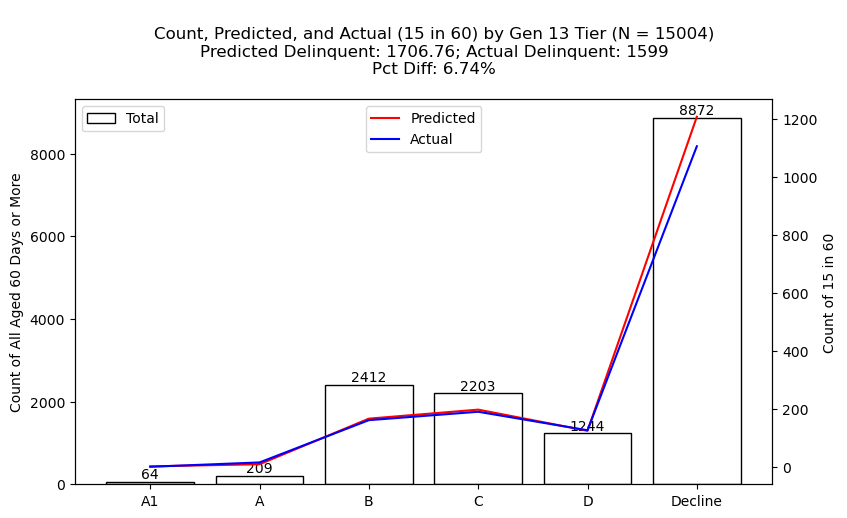

,Tier,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
1,A1,64,0,1.412930,0.000000,0.022077
0,A,209,15,8.722172,0.071770,0.041733
2,B,2412,161,166.217235,0.066750,0.068913
3,C,2203,190,197.348297,0.086246,0.089582
4,D,1244,126,124.329278,0.101286,0.099943
5,Decline,8872,1107,1208.730442,0.124775,0.136241


In [29]:
# tier
df = analyze_by_tier(
    int_dpd=int_dpd,
    int_dob=int_dob,
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_tier(
    int_dpd=int_dpd,
    int_dob=int_dob,
    df=df,
    str_dirname_output=str_dirname_output,
)
# show
df

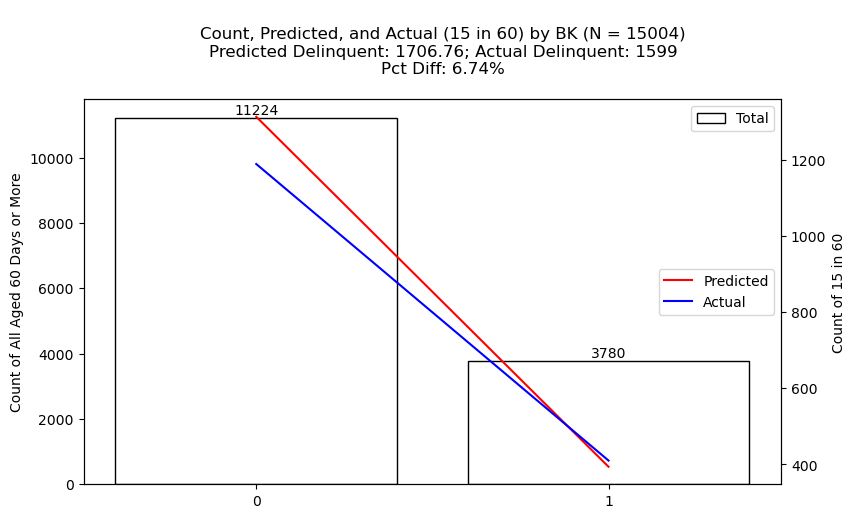

,BK,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
0,0,11224,1189,1313.106420,0.105934,0.116991
1,1,3780,410,393.653934,0.108466,0.104141


In [30]:
# bk
df = analyze_by_bk(
    int_dpd=int_dpd,
    int_dob=int_dob,
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_bk(
    int_dpd=int_dpd,
    int_dob=int_dob,
    df=df,
    str_dirname_output=str_dirname_output,
)
# show
df

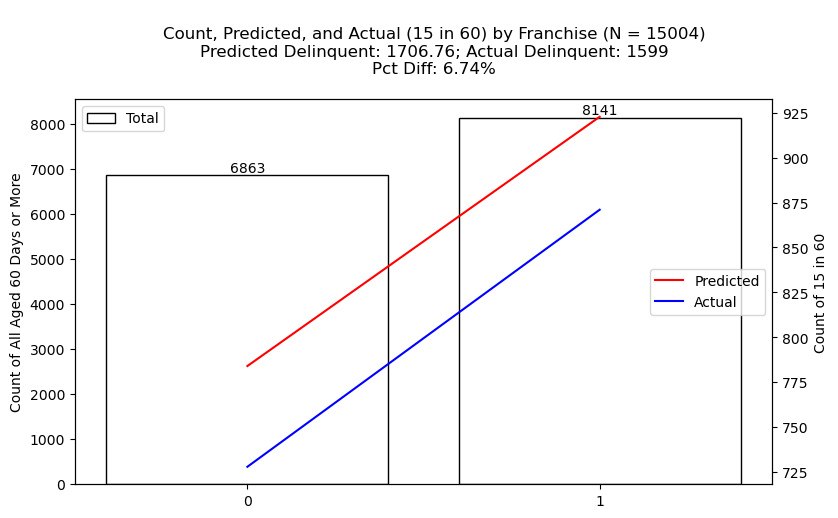

,Franchise,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
0,0,6863,728,784.051606,0.106076,0.114243
1,1,8141,871,922.708749,0.106989,0.113341


In [31]:
# dealer
df = analyze_by_dealer(
    int_dpd=int_dpd,
    int_dob=int_dob,
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_dealer(
    int_dpd=int_dpd,
    int_dob=int_dob,
    df=df,
    str_dirname_output=str_dirname_output,
)
# show
df

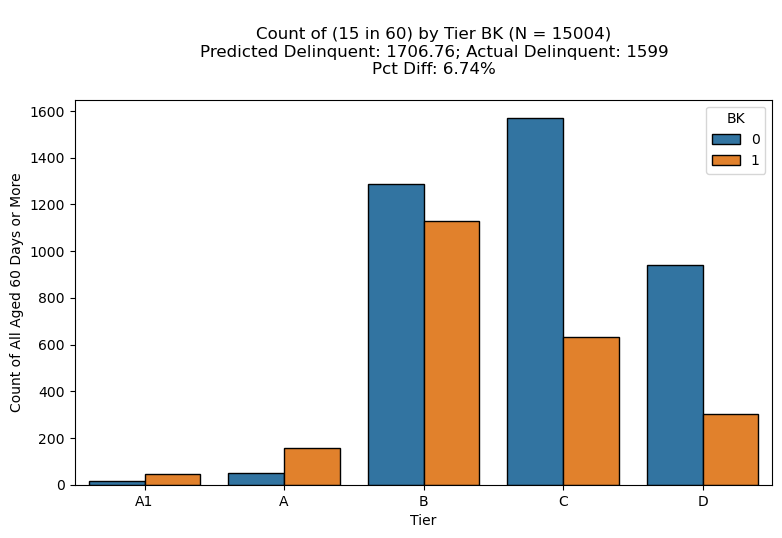

,Tier,BK,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
2,A1,0,17,0,0.287560,0.000000,0.016915
3,A1,1,47,0,1.125371,0.000000,0.023944
0,A,0,52,5,2.254671,0.096154,0.043359
1,A,1,157,10,6.467501,0.063694,0.041194
4,B,0,1285,93,91.042751,0.072374,0.070850
5,B,1,1127,68,75.174484,0.060337,0.066703
6,C,0,1569,123,138.644547,0.078394,0.088365
7,C,1,634,67,58.703750,0.105678,0.092593
8,D,0,940,92,92.542769,0.097872,0.098450
9,D,1,304,34,31.786509,0.111842,0.104561


In [32]:
# tier bk
df = analyze_by_tier_bk(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_tier_bk(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    df=df, 
    str_dirname_output=str_dirname_output,
)
# show
df

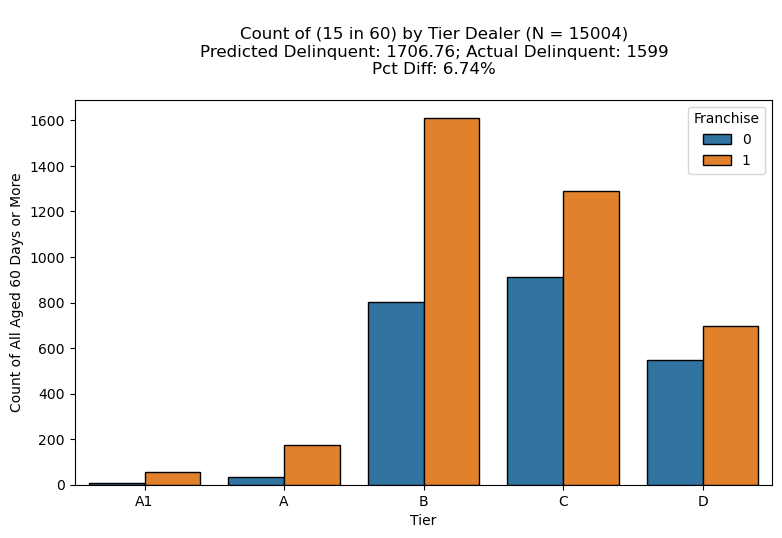

,Tier,Franchise,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
2,A1,0,6,0,0.122347,0.000000,0.020391
3,A1,1,58,0,1.290583,0.000000,0.022251
0,A,0,33,2,1.281296,0.060606,0.038827
1,A,1,176,13,7.440876,0.073864,0.042278
4,B,0,802,48,52.649328,0.059850,0.065648
5,B,1,1610,113,113.567907,0.070186,0.070539
6,C,0,912,60,76.121530,0.065789,0.083467
7,C,1,1291,130,121.226767,0.100697,0.093901
8,D,0,546,50,51.014112,0.091575,0.093432
9,D,1,698,76,73.315166,0.108883,0.105036


In [33]:
# tier dealer
df = analyze_by_tier_dealer(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_tier_dealer(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    df=df, 
    str_dirname_output=str_dirname_output,
)
# show
df

#### Analysis 30 in 180

In [34]:
# 30 in 180
int_dpd = 30
int_dob = 180

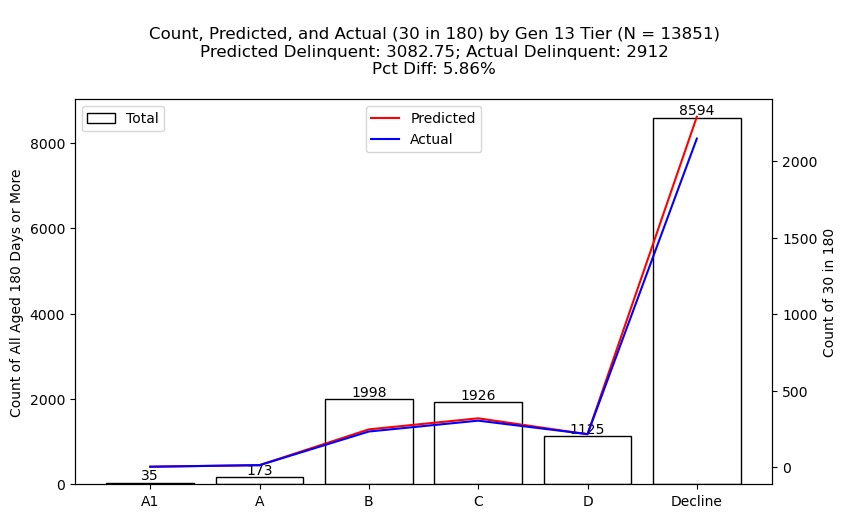

,Tier,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
1,A1,35,2,1.409741,0.057143,0.040278
0,A,173,12,12.181377,0.069364,0.070413
2,B,1998,232,246.164411,0.116116,0.123205
3,C,1926,303,318.375841,0.157321,0.165304
4,D,1125,215,214.148525,0.191111,0.190354
5,Decline,8594,2148,2290.468604,0.249942,0.266520


In [35]:
# tier
df = analyze_by_tier(
    int_dpd=int_dpd,
    int_dob=int_dob,
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_tier(
    int_dpd=int_dpd,
    int_dob=int_dob,
    df=df,
    str_dirname_output=str_dirname_output,
)
# show
df

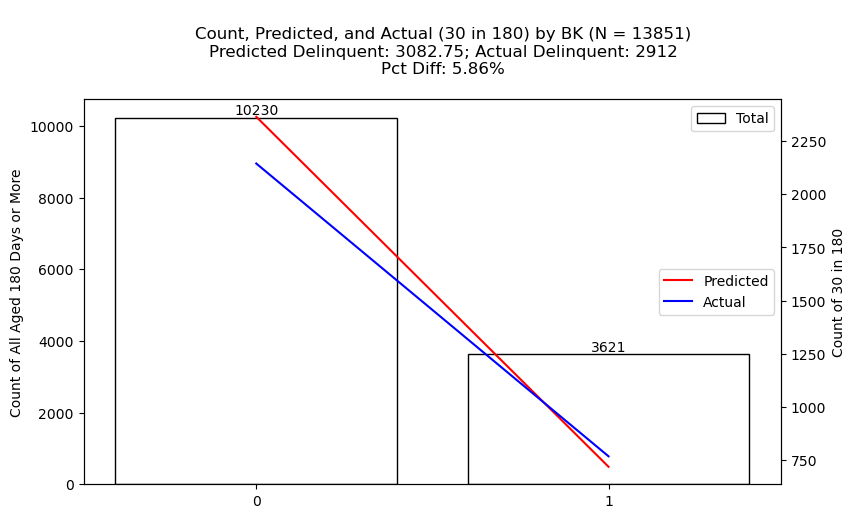

,BK,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
0,0,10230,2145,2365.002414,0.209677,0.231183
1,1,3621,767,717.746087,0.211820,0.198218


In [36]:
# bk
df = analyze_by_bk(
    int_dpd=int_dpd,
    int_dob=int_dob,
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_bk(
    int_dpd=int_dpd,
    int_dob=int_dob,
    df=df,
    str_dirname_output=str_dirname_output,
)
# show
df

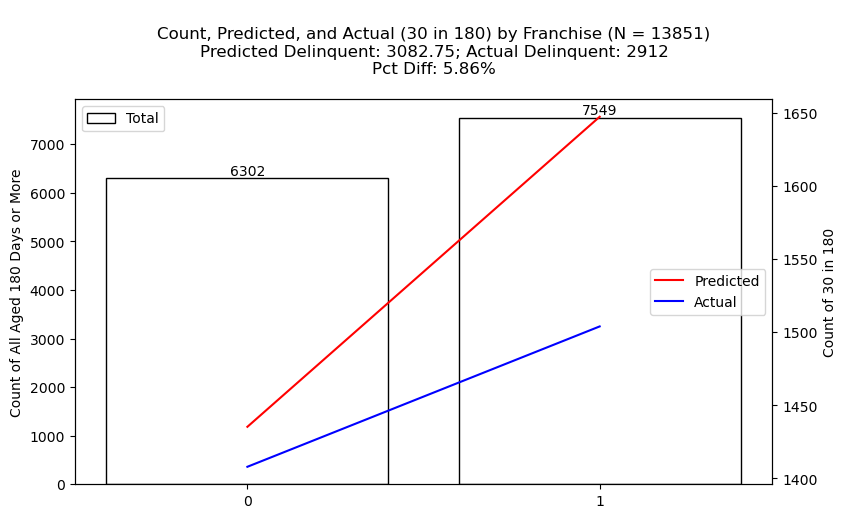

,Franchise,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
0,0,6302,1408,1435.345772,0.223421,0.227760
1,1,7549,1504,1647.402729,0.199232,0.218228


In [37]:
# dealer
df = analyze_by_dealer(
    int_dpd=int_dpd,
    int_dob=int_dob,
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_dealer(
    int_dpd=int_dpd,
    int_dob=int_dob,
    df=df,
    str_dirname_output=str_dirname_output,
)
# show
df

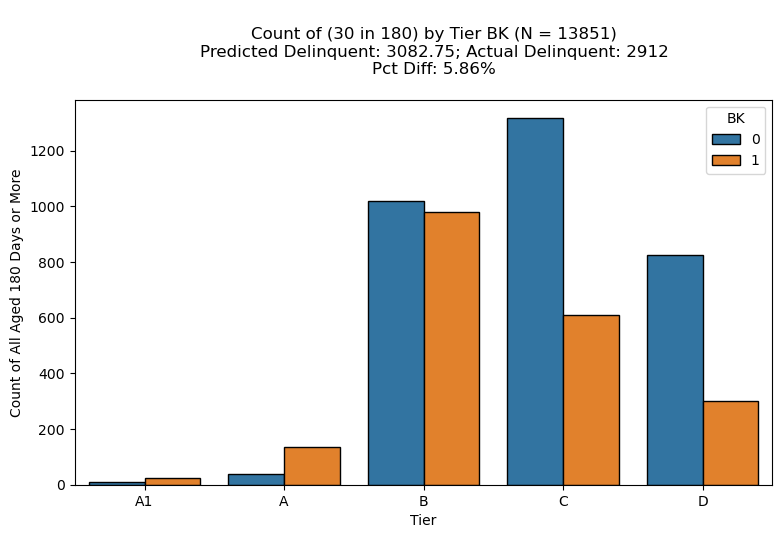

,Tier,BK,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
2,A1,0,10,1,0.328829,0.100000,0.032883
3,A1,1,25,1,1.080912,0.040000,0.043236
0,A,0,39,6,2.846092,0.153846,0.072977
1,A,1,134,6,9.335286,0.044776,0.069666
4,B,0,1020,141,129.394775,0.138235,0.126858
5,B,1,978,91,116.769636,0.093047,0.119396
6,C,0,1317,189,216.050903,0.143508,0.164048
7,C,1,609,114,102.324938,0.187192,0.168021
8,D,0,824,152,155.688003,0.184466,0.188942
9,D,1,301,63,58.460522,0.209302,0.194221


In [38]:
# tier bk
df = analyze_by_tier_bk(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_tier_bk(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    df=df, 
    str_dirname_output=str_dirname_output,
)

# show
df

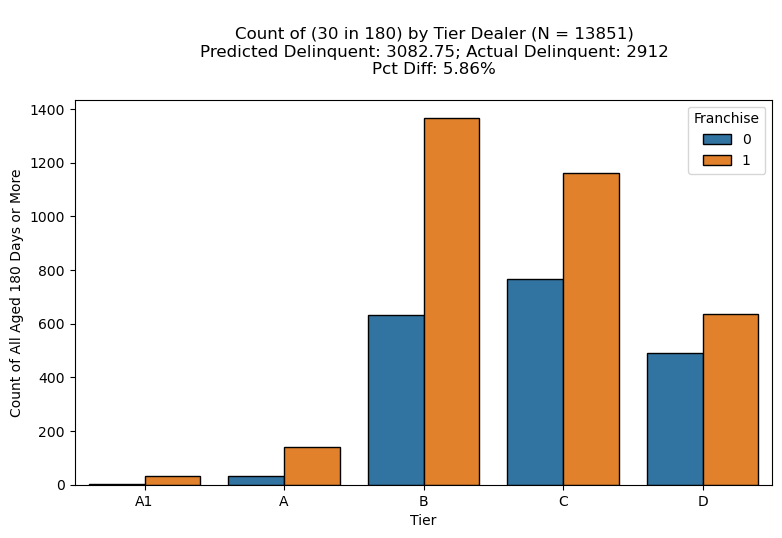

,Tier,Franchise,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
2,A1,0,3,0,0.089348,0.000000,0.029783
3,A1,1,32,2,1.320394,0.062500,0.041262
0,A,0,33,2,2.183415,0.060606,0.066164
1,A,1,140,10,9.997962,0.071429,0.071414
4,B,0,632,80,73.612337,0.126582,0.116475
5,B,1,1366,152,172.552074,0.111274,0.126319
6,C,0,766,117,120.234217,0.152742,0.156964
7,C,1,1160,186,198.141625,0.160345,0.170812
8,D,0,489,91,88.928673,0.186094,0.181858
9,D,1,636,124,125.219852,0.194969,0.196887


In [39]:
# tier dealer
df = analyze_by_tier_dealer(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_tier_dealer(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    df=df, 
    str_dirname_output=str_dirname_output,
)
# show
df

#### Analysis 30 in 360

In [40]:
# 30 in 360
int_dpd = 30
int_dob = 360

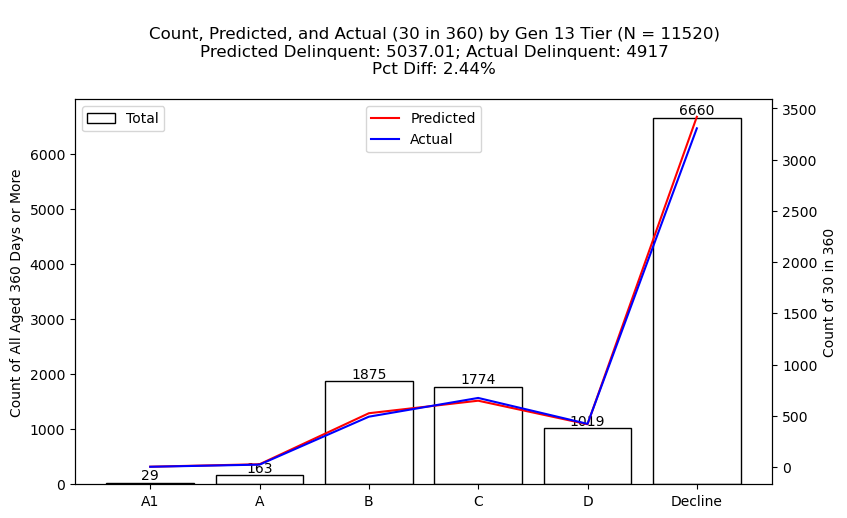

,Tier,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
1,A1,29,2,2.781318,0.068966,0.095908
0,A,163,23,26.695644,0.141104,0.163777
2,B,1875,491,524.694593,0.261867,0.279837
3,C,1774,674,647.095522,0.379932,0.364766
4,D,1019,421,416.941018,0.413150,0.409167
5,Decline,6660,3306,3418.799610,0.496396,0.513333


In [41]:
# tier
df = analyze_by_tier(
    int_dpd=int_dpd,
    int_dob=int_dob,
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_tier(
    int_dpd=int_dpd,
    int_dob=int_dob,
    df=df,
    str_dirname_output=str_dirname_output,
)
# show
df

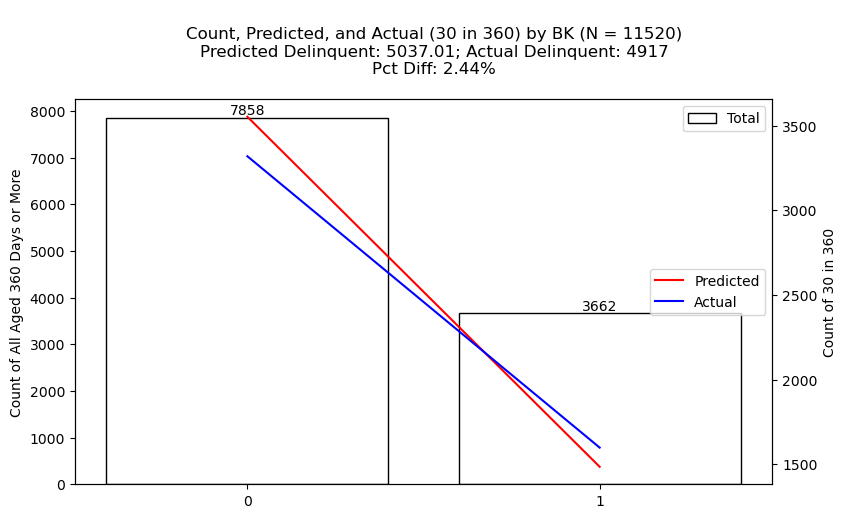

,BK,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
0,0,7858,3319,3552.290875,0.422372,0.452060
1,1,3662,1598,1484.716831,0.436374,0.405439


In [42]:
# bk
df = analyze_by_bk(
    int_dpd=int_dpd,
    int_dob=int_dob,
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_bk(
    int_dpd=int_dpd,
    int_dob=int_dob,
    df=df,
    str_dirname_output=str_dirname_output,
)
# show
df

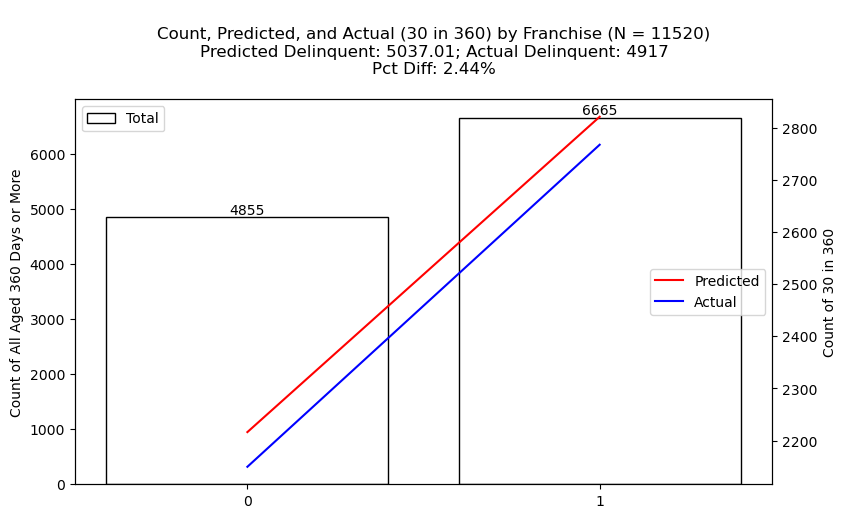

,Franchise,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
0,0,4855,2150,2216.458788,0.442842,0.456531
1,1,6665,2767,2820.548917,0.415154,0.423188


In [43]:
# dealer
df = analyze_by_dealer(
    int_dpd=int_dpd,
    int_dob=int_dob,
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_dealer(
    int_dpd=int_dpd,
    int_dob=int_dob,
    df=df,
    str_dirname_output=str_dirname_output,
)
# show
df

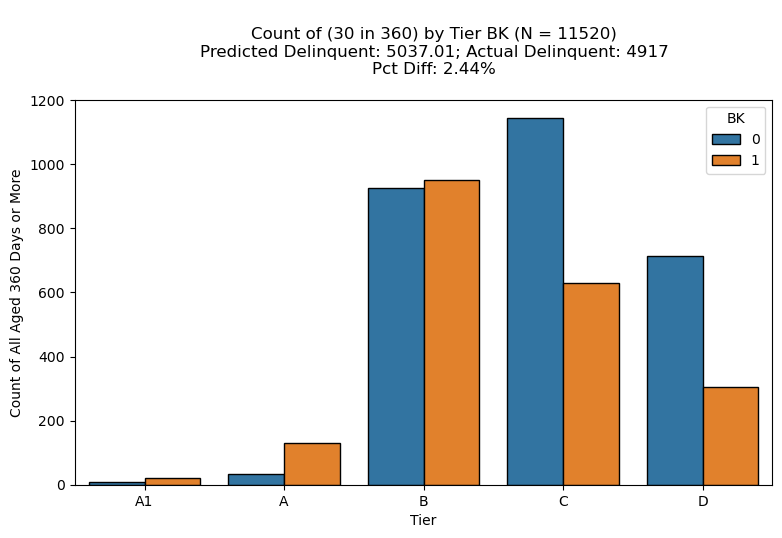

,Tier,BK,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
2,A1,0,9,0,0.904303,0.000000,0.100478
3,A1,1,20,2,1.877015,0.100000,0.093851
0,A,0,33,3,5.899962,0.090909,0.178787
1,A,1,130,20,20.795681,0.153846,0.159967
4,B,0,925,250,265.936013,0.270270,0.287498
5,B,1,950,241,258.758580,0.253684,0.272377
6,C,0,1144,415,415.482787,0.362762,0.363184
7,C,1,630,259,231.612735,0.411111,0.367639
8,D,0,713,285,291.155613,0.399719,0.408353
9,D,1,306,136,125.785405,0.444444,0.411063


In [44]:
# tier bk
df = analyze_by_tier_bk(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_tier_bk(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    df=df, 
    str_dirname_output=str_dirname_output,
)

# show
df

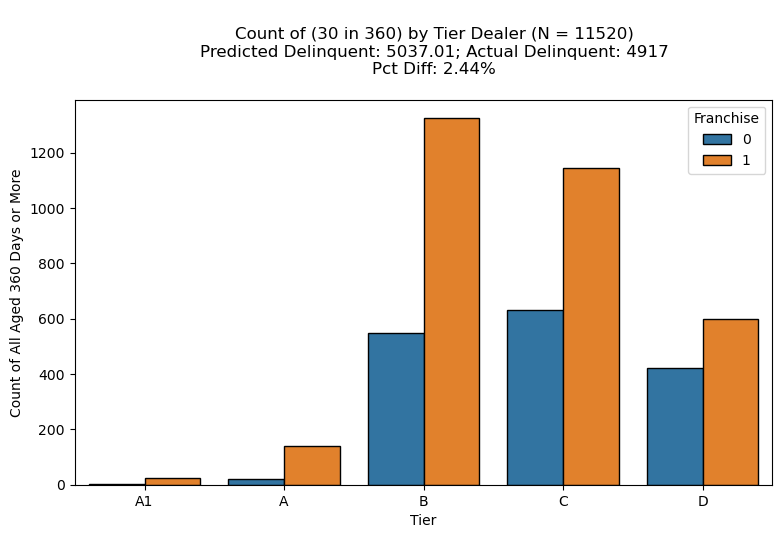

,Tier,Franchise,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
2,A1,0,3,0,0.210883,0.000000,0.070294
3,A1,1,26,2,2.570434,0.076923,0.098863
0,A,0,22,5,3.395187,0.227273,0.154327
1,A,1,141,18,23.300457,0.127660,0.165251
4,B,0,550,170,152.825869,0.309091,0.277865
5,B,1,1325,321,371.868724,0.242264,0.280656
6,C,0,631,230,228.294135,0.364501,0.361797
7,C,1,1143,444,418.801388,0.388451,0.366405
8,D,0,420,159,170.993925,0.378571,0.407128
9,D,1,599,262,245.947093,0.437396,0.410596


In [45]:
# tier dealer
df = analyze_by_tier_dealer(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_tier_dealer(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    df=df, 
    str_dirname_output=str_dirname_output,
)
# show
df

#### Analysis 60 in 720

In [46]:
# 60 in 720
int_dpd = 60
int_dob = 720

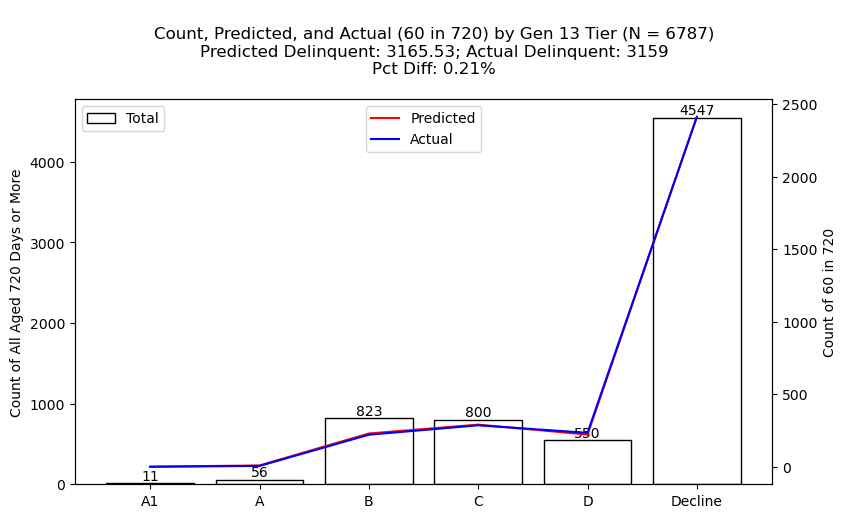

,Tier,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
1,A1,11,0,1.068430,0.000000,0.097130
0,A,56,6,9.011939,0.107143,0.160927
2,B,823,221,229.469559,0.268530,0.278821
3,C,800,286,290.507517,0.357500,0.363134
4,D,550,234,222.046994,0.425455,0.403722
5,Decline,4547,2412,2413.423637,0.530460,0.530773


In [47]:
# tier
df = analyze_by_tier(
    int_dpd=int_dpd,
    int_dob=int_dob,
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_tier(
    int_dpd=int_dpd,
    int_dob=int_dob,
    df=df,
    str_dirname_output=str_dirname_output,
)
# show
df

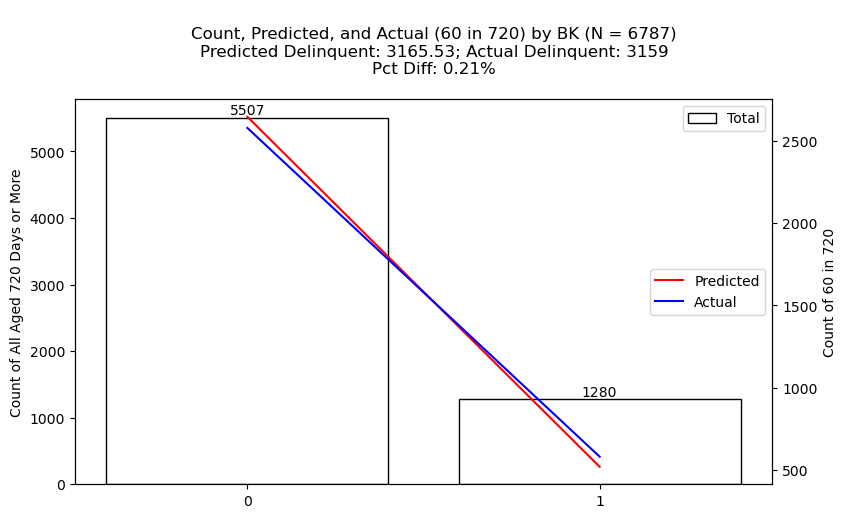

,BK,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
0,0,5507,2577,2644.731766,0.467950,0.480249
1,1,1280,582,520.796310,0.454688,0.406872


In [48]:
# bk
df = analyze_by_bk(
    int_dpd=int_dpd,
    int_dob=int_dob,
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_bk(
    int_dpd=int_dpd,
    int_dob=int_dob,
    df=df,
    str_dirname_output=str_dirname_output,
)
# show
df

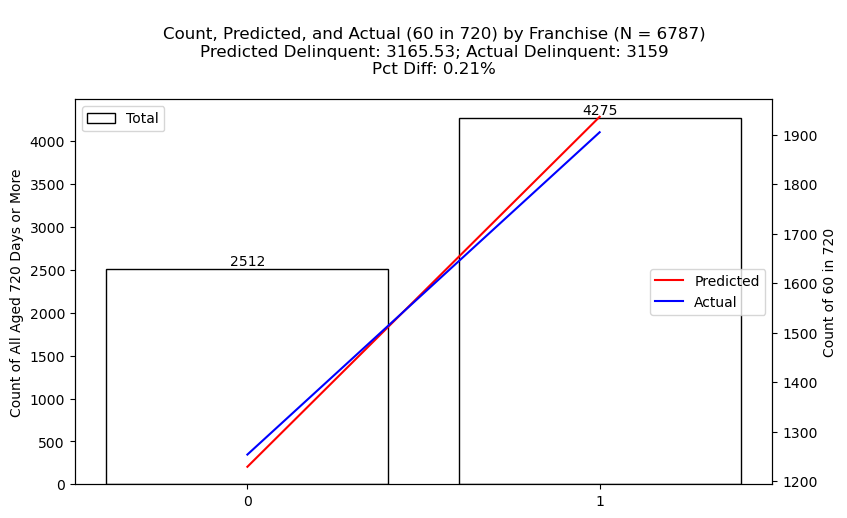

,Franchise,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
0,0,2512,1254,1229.322564,0.499204,0.489380
1,1,4275,1905,1936.205512,0.445614,0.452914


In [49]:
# dealer
df = analyze_by_dealer(
    int_dpd=int_dpd,
    int_dob=int_dob,
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_dealer(
    int_dpd=int_dpd,
    int_dob=int_dob,
    df=df,
    str_dirname_output=str_dirname_output,
)
# show
df

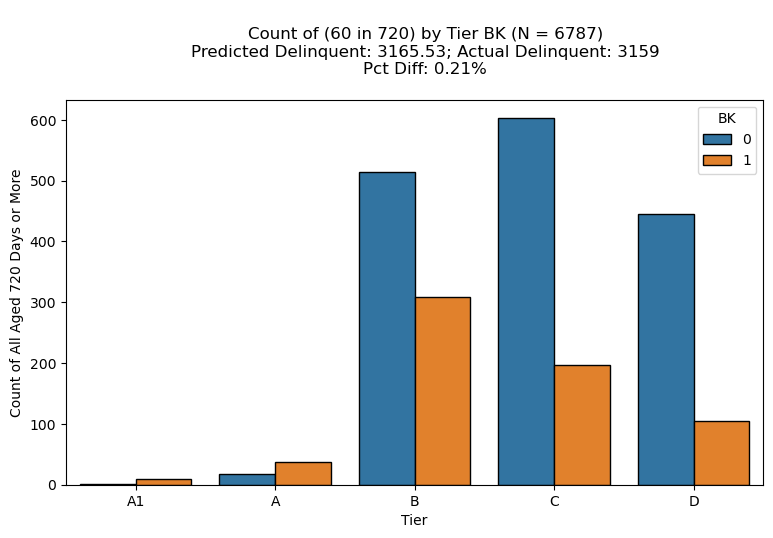

,Tier,BK,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
2,A1,0,2,0,0.381089,0.000000,0.190544
3,A1,1,9,0,0.687341,0.000000,0.076371
0,A,0,18,3,3.142923,0.166667,0.174607
1,A,1,38,3,5.869016,0.078947,0.154448
4,B,0,515,135,148.931538,0.262136,0.289187
5,B,1,308,86,80.538021,0.279221,0.261487
6,C,0,603,215,220.935447,0.356551,0.366394
7,C,1,197,71,69.572070,0.360406,0.353158
8,D,0,445,193,180.840378,0.433708,0.406383
9,D,1,105,41,41.206616,0.390476,0.392444


In [50]:
# tier bk
df = analyze_by_tier_bk(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_tier_bk(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    df=df, 
    str_dirname_output=str_dirname_output,
)

# show
df

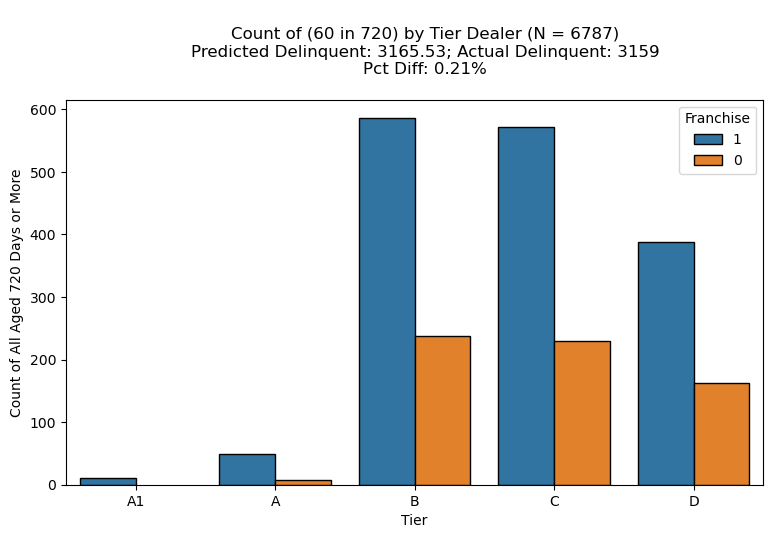

,Tier,Franchise,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
2,A1,1,11,0,1.068430,0.000000,0.097130
0,A,0,7,1,1.105420,0.142857,0.157917
1,A,1,49,5,7.906518,0.102041,0.161358
3,B,0,237,68,66.734804,0.286920,0.281581
4,B,1,586,153,162.734755,0.261092,0.277704
5,C,0,229,86,83.934083,0.375546,0.366524
6,C,1,571,200,206.573433,0.350263,0.361775
7,D,0,162,70,66.351628,0.432099,0.409578
8,D,1,388,164,155.695367,0.422680,0.401277
9,Decline,0,1877,1029,1011.196629,0.548215,0.538730


In [51]:
# tier dealer
df = analyze_by_tier_dealer(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_tier_dealer(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    df=df, 
    str_dirname_output=str_dirname_output,
)
# show
df

#### Analysis 30 in 90

In [52]:
# 30 in 90
int_dpd = 30
int_dob = 90

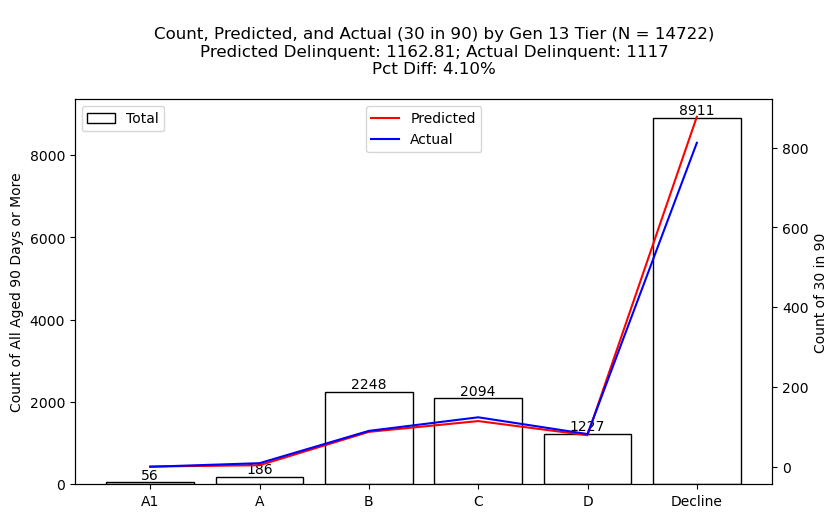

,Tier,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
1,A1,56,0,0.603388,0.000000,0.010775
0,A,186,9,3.836463,0.048387,0.020626
2,B,2248,90,87.529706,0.040036,0.038937
3,C,2094,124,114.571462,0.059217,0.054714
4,D,1227,82,79.038563,0.066830,0.064416
5,Decline,8911,812,877.227982,0.091123,0.098443


In [53]:
# tier
df = analyze_by_tier(
    int_dpd=int_dpd,
    int_dob=int_dob,
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_tier(
    int_dpd=int_dpd,
    int_dob=int_dob,
    df=df,
    str_dirname_output=str_dirname_output,
)
# show
df

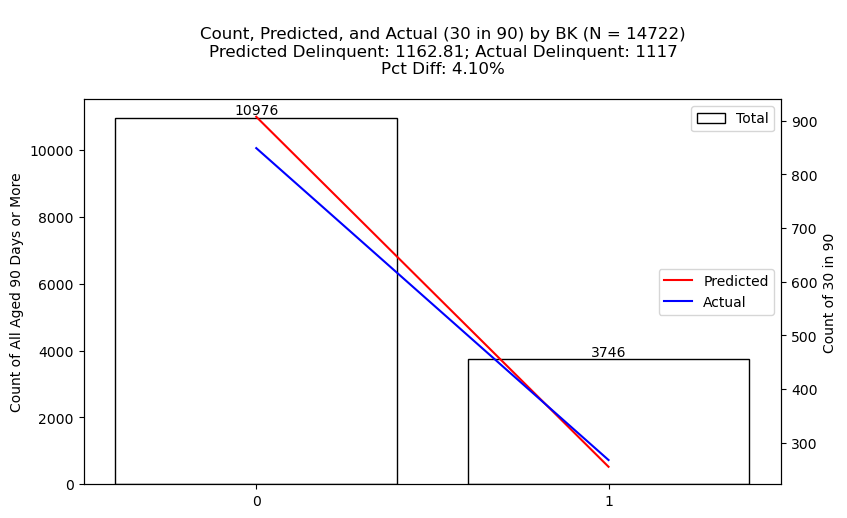

,BK,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
0,0,10976,849,907.383336,0.077351,0.082670
1,1,3746,268,255.424228,0.071543,0.068186


In [54]:
# bk
df = analyze_by_bk(
    int_dpd=int_dpd,
    int_dob=int_dob,
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_bk(
    int_dpd=int_dpd,
    int_dob=int_dob,
    df=df,
    str_dirname_output=str_dirname_output,
)
# show
df

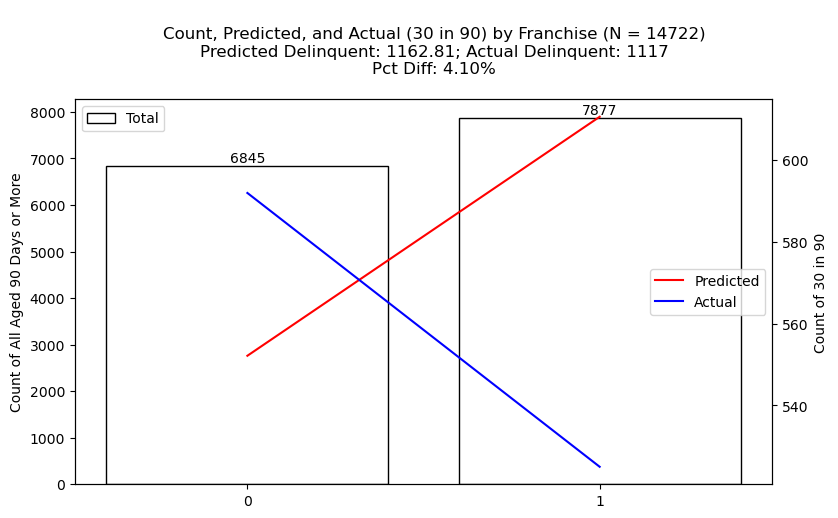

,Franchise,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
0,0,6845,592,552.166480,0.086486,0.080667
1,1,7877,525,610.641084,0.066650,0.077522


In [55]:
# dealer
df = analyze_by_dealer(
    int_dpd=int_dpd,
    int_dob=int_dob,
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_dealer(
    int_dpd=int_dpd,
    int_dob=int_dob,
    df=df,
    str_dirname_output=str_dirname_output,
)
# show
df

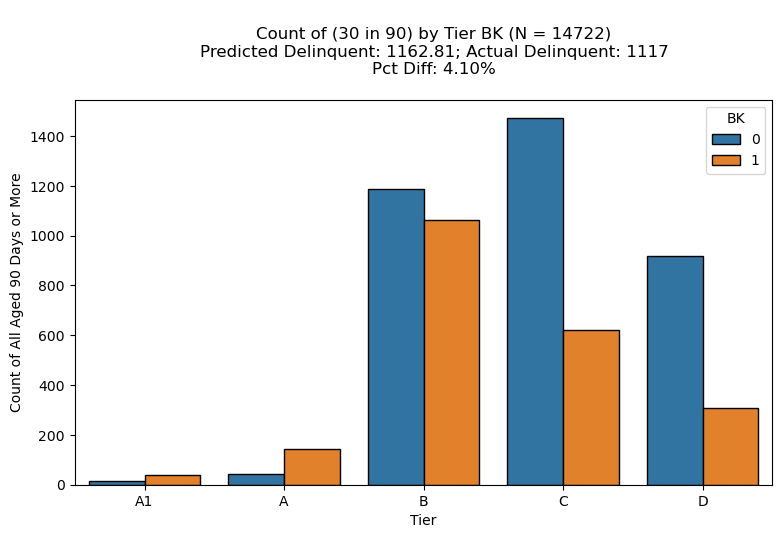

,Tier,BK,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
2,A1,0,15,0,0.140543,0.000000,0.009370
3,A1,1,41,0,0.462846,0.000000,0.011289
0,A,0,42,4,0.914572,0.095238,0.021776
1,A,1,144,5,2.921891,0.034722,0.020291
4,B,0,1186,53,48.078102,0.044688,0.040538
5,B,1,1062,37,39.451604,0.034840,0.037148
6,C,0,1472,85,79.917878,0.057745,0.054292
7,C,1,622,39,34.653585,0.062701,0.055713
8,D,0,919,57,58.605088,0.062024,0.063770
9,D,1,308,25,20.433475,0.081169,0.066342


In [56]:
# tier bk
df = analyze_by_tier_bk(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_tier_bk(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    df=df, 
    str_dirname_output=str_dirname_output,
)

# show
df

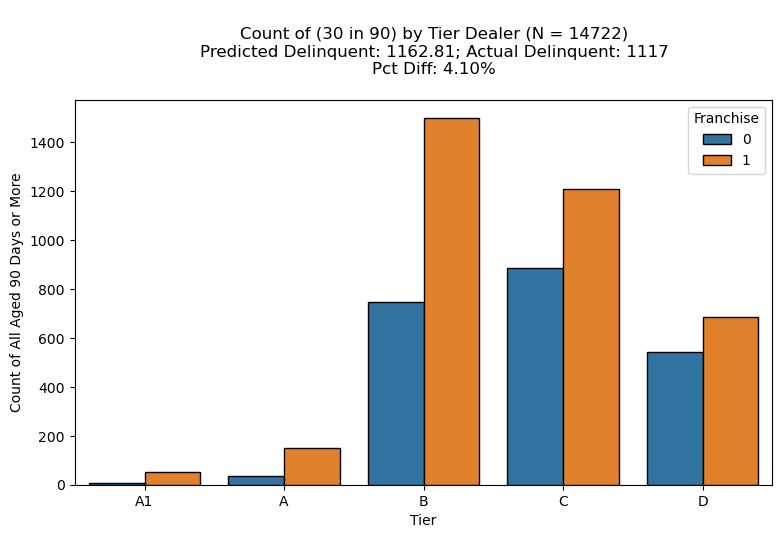

,Tier,Franchise,Count,Actual,Predicted,Actual Bad Rate,Predicted Bad Rate
2,A1,0,6,0,0.051929,0.000000,0.008655
3,A1,1,50,0,0.551459,0.000000,0.011029
0,A,0,34,2,0.622498,0.058824,0.018309
1,A,1,152,7,3.213965,0.046053,0.021145
4,B,0,749,31,27.862918,0.041389,0.037200
5,B,1,1499,59,59.666788,0.039360,0.039804
6,C,0,887,49,45.341626,0.055242,0.051118
7,C,1,1207,75,69.229836,0.062138,0.057357
8,D,0,543,40,33.199695,0.073665,0.061141
9,D,1,684,42,45.838868,0.061404,0.067016


In [57]:
# tier dealer
df = analyze_by_tier_dealer(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    dict_df_holdout=dict_df_holdout,
)
# plot
plot_by_tier_dealer(
    int_dpd=int_dpd, 
    int_dob=int_dob, 
    df=df, 
    str_dirname_output=str_dirname_output,
)
# show
df